In [7]:
from script import project_dedalus_to_x_y_dye, params_to_dedalus_filename, run_superfv_sim
import matplotlib.pyplot as plt

Re_base10 = 5
Nref = 4096
density_jump = 2
t_sim_approx = 4

NDOF = 2048
p = 3

In [8]:
dedalus = params_to_dedalus_filename(Re_base10, Nref, density_jump, t_sim_approx)

In [9]:
superfv_sim = run_superfv_sim(
    name="",
    p=p,
    NDOF=NDOF,
    Re_base10=Re_base10,
    Nref=Nref,
    density_jump=density_jump,
    t_sim_approx=t_sim_approx,
    rtol=1e-5,
)

t_exact from '/scratch/gpfs/jp7427/FVvsSD/Lecoanet_dataset/5_4096_2_4.h5' is 4.0000216372299695
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/lecoanet/FV__p=3_NDOF=2048_5_4096_2_4'


In [4]:
# spd_sim = run_spd_sim(
#         name="",
#         p=p,
#         NDOF=NDOF,
#         Re_base10=Re_base10,
#         Nref=Nref,
#         density_jump=density_jump,
#         t_sim_approx=t_sim_approx,
#         tolerance=1e-5,
#     )

t_exact from '/scratch/gpfs/jp7427/FVvsSD/Lecoanet_dataset/5_4096_2_4.h5' is 4.0000216372299695
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/lecoanet/SD__p=7_NDOF=1024_5_4096_2_4'


In [10]:
def plot_dedalus(ax, filename):
    ax.set_aspect("equal")
    ax.set_ylim(0, 1.0)
    
    x, y, c = project_dedalus_to_x_y_dye(dedalus)
    return ax.pcolormesh(x, y, c.T, shading='nearest')
    

def plot_fv(ax, sim):
    ax.set_aspect("equal")
    ax.set_ylim(0, 1.0)
    
    x_fv, y_fv, _ = sim.mesh.faces
    z_fv = sim.snapshot_history[-1].w[5, :, :, 0].T
    return ax.pcolormesh(x_fv, y_fv, z_fv)


def plot_sd(ax, sim):
    ax.set_aspect("equal")
    ax.set_ylim(0, 1.0)

    x_sd = sim.regular_faces()[0]
    y_sd = sim.regular_faces()[1]
    z_sd = sim.transpose_to_fv(sim.regular_mesh(sim.dm.W_cv))[5]
    return ax.pcolormesh(x_sd, y_sd, z_sd)

-> Loaded snapshot at t=4.0000216372299695 from /scratch/gpfs/jp7427/FVvsSD/lecoanet/FV__p=3_NDOF=2048_5_4096_2_4/output_000001.pkl.


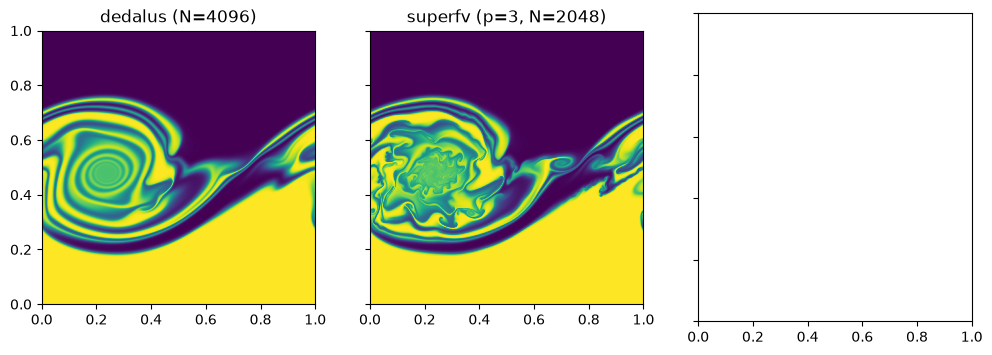

In [11]:
fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(12, 4))

axs[0].set_title(f"dedalus (N={Nref})")
plot_dedalus(axs[0], dedalus)

axs[1].set_title(f"superfv (p={p}, N={NDOF})")
plot_fv(axs[1], superfv_sim)

# axs[2].set_title(f"spd (p={p}, N={NDOF})")
# plot_sd(axs[2], spd_sim)

fig.savefig(f"t={t_sim_approx}.png", dpi=300, bbox_inches="tight")